# Analisis Data Menggunakan Random Forest
## Studi Kasus: Adult Income Dataset

---

> **Proyek:** Klasifikasi Pendapatan menggunakan Decision Tree & Random Forest  
> **Dataset:** Adult Census Income (UCI Machine Learning Repository)  
> **Tools:** KNIME Analytics Platform + Python (Scikit-learn)  
> **Target Variabel:** `income` — apakah seseorang berpendapatan `<=50K` atau `>50K` per tahun

---

## 📋 Daftar Isi

1. [Pendahuluan](#1-pendahuluan)
2. [Dataset](#2-dataset)
3. [KNIME Workflow](#3-knime-workflow)
4. [Konsep Algoritma](#4-konsep-algoritma)
5. [Implementasi Python](#5-implementasi-python)
6. [Hasil dan Evaluasi](#6-hasil-dan-evaluasi)
7. [Perbandingan Model](#7-perbandingan-model)
8. [Feature Importance](#8-feature-importance)
9. [Kesimpulan](#9-kesimpulan)

---

## 1. Pendahuluan

Proyek ini membangun sistem klasifikasi untuk memprediksi apakah pendapatan seseorang melebihi \$50.000 per tahun berdasarkan data sensus. Dua model digunakan dan dibandingkan:

- **Decision Tree** — model tunggal berbasis pohon keputusan
- **Random Forest** — ensemble dari 50 pohon keputusan

Random Forest dipilih sebagai model utama karena kemampuannya mengatasi *overfitting* yang sering terjadi pada Decision Tree tunggal, serta menghasilkan akurasi yang lebih stabil dan robust.

---

## 2. Dataset

### 2.1 Informasi Umum

| Properti | Detail |
|---|---|
| Sumber | UCI Machine Learning Repository — Adult Dataset |
| Jumlah Record | 32.561 baris |
| Jumlah Fitur | 14 fitur input + 1 target |
| Split | 80% Training / 20% Testing |
| Task | Binary Classification |

### 2.2 Deskripsi Fitur

| # | Nama Kolom | Tipe | Deskripsi |
|---|---|---|---|
| 1 | `age` | Numerik | Usia individu |
| 2 | `workclass` | Kategorik | Jenis pekerjaan (Private, Gov, Self-emp, dll.) |
| 3 | `fnlwgt` | Numerik | Final weight (bobot demografis sensus) |
| 4 | `education` | Kategorik | Tingkat pendidikan (Bachelors, HS-grad, dll.) |
| 5 | `education_num` | Numerik | Lama pendidikan dalam tahun |
| 6 | `marital_status` | Kategorik | Status pernikahan |
| 7 | `occupation` | Kategorik | Jenis pekerjaan/profesi |
| 8 | `relationship` | Kategorik | Status hubungan keluarga |
| 9 | `race` | Kategorik | Ras |
| 10 | `sex` | Kategorik | Jenis kelamin |
| 11 | `capital_gain` | Numerik | Keuntungan modal |
| 12 | `capital_loss` | Numerik | Kerugian modal |
| 13 | `hours_per_week` | Numerik | Jam kerja per minggu |
| 14 | `native_country` | Kategorik | Negara asal |
| 15 | `income` | **Target** | `<=50K` atau `>50K` |

### 2.3 Distribusi Target

```
income
<=50K    24.720  (75.9%)
>50K      7.841  (24.1%)
```

> ⚠️ **Catatan:** Dataset bersifat *imbalanced* — kelas `<=50K` jauh lebih banyak dibanding `>50K`. Hal ini perlu diperhatikan saat mengevaluasi performa model.

### 2.4 Statistik Deskriptif Fitur Numerik

| Fitur | Min | Max | Mean | Std |
|---|---|---|---|---|
| `age` | 17 | 90 | 38.58 | 13.64 |
| `fnlwgt` | 12.285 | 1.484.705 | 189.778 | 105.550 |
| `education_num` | 1 | 16 | 10.08 | 2.57 |
| `capital_gain` | 0 | 99.999 | 1.077 | 7.385 |
| `capital_loss` | 0 | 4.356 | 87.30 | 402.96 |
| `hours_per_week` | 1 | 99 | 40.44 | 12.35 |

---

## 3. KNIME Workflow

### 3.1 Gambaran Umum Workflow

Workflow KNIME yang digunakan terdiri dari dua bagian utama:

![Random Forest](random_forest.png)

### 3.2 Penjelasan Setiap Node

#### 🟠 CSV Reader
- **Fungsi:** Membaca file `adults.csv` ke dalam KNIME sebagai tabel data.
- **Konfigurasi:** Format CSV standar, otomatis mendeteksi tipe kolom.

#### 🟡 Table Partitioner
- **Fungsi:** Membagi dataset menjadi dua bagian:
  - **80%** untuk training (pelatihan model)
  - **20%** untuk testing (evaluasi model)
- **Metode:** Stratified sampling untuk menjaga proporsi kelas target.

---

### 3.3 Bagian 1: Decision Tree (Pohon Tunggal)

#### 🟢 Decision Tree Learner
- **Fungsi:** Melatih satu model Decision Tree dari data training.
- **Parameter:**
  - Minimum node size: **2**
  - Jumlah pohon: **1**
- **Output:** 1 model decision tree.

#### 🟢 Decision Tree View (JavaScript) *(deprecated)*
- **Fungsi:** Visualisasi interaktif struktur pohon keputusan.
- **Status:** Node ini sudah *deprecated* di versi KNIME terbaru, namun masih berfungsi untuk tujuan eksplorasi.

#### 🟢 Decision Tree Predictor
- **Fungsi:** Mengaplikasikan model Decision Tree yang telah dilatih ke data testing.
- **Output:** Kolom prediksi tambahan pada tabel testing.

#### 🔵 Scorer (JavaScript)
- **Fungsi:** Menghitung metrik evaluasi klasifikasi:
  - Confusion Matrix
  - Accuracy, Precision, Recall, F1-Score
- **Output:** Tabel performa model.

---

### 3.4 Bagian 2: Random Forest (Ensemble 50 Pohon)

#### 🟢 Random Forest Learner
- **Fungsi:** Melatih Random Forest dari data training.
- **Parameter:**
  - Jumlah pohon: **50 decision trees**
  - Minimum node size: **2**
- **Output:** Model ensemble dari 50 pohon.

#### 🟢 Random Forest Predictor
- **Fungsi:** Mengaplikasikan model Random Forest ke data testing.
- **Mekanisme voting:** Prediksi akhir ditentukan oleh mayoritas suara dari 50 pohon.

#### 🔵 Scorer (JavaScript)
- **Fungsi:** Sama seperti scorer Decision Tree — mengevaluasi performa Random Forest.

#### 🔵 Tree Ensemble Statistics
- **Fungsi:** Menampilkan statistik ensemble seperti feature importance, distribusi error per pohon, dan statistik agregat.

---

### 3.5 Bagian 3: Export PMML (Opsional)

#### 🟤 Tree Ensemble Model Extract
- **Fungsi:** Mengekstrak model Random Forest dari format internal KNIME.

#### 🟤 Table to PMML Ensemble
- **Fungsi:** Mengekspor model ke format **PMML (Predictive Model Markup Language)** — format standar untuk interoperabilitas model machine learning antar platform.

---

## 4. Konsep Algoritma

### 4.1 Decision Tree

Decision Tree adalah algoritma supervised learning berbentuk pohon di mana setiap *internal node* merepresentasikan sebuah tes pada fitur, setiap *branch* merepresentasikan hasil tes, dan setiap *leaf node* merepresentasikan label kelas.

**Cara Kerja:**

```
Root Node (semua data)
    ├─ [capital_gain <= threshold]
    │       ├─ [age <= threshold] → Prediksi: <=50K
    │       └─ [education_num > threshold] → Prediksi: >50K
    └─ [capital_gain > threshold]
            ├─ [relationship = Husband] → Prediksi: >50K
            └─ [hours_per_week <= 40] → Prediksi: <=50K
```

**Kriteria Pemisahan (Splitting Criterion):**
- **Gini Impurity:** Mengukur seberapa sering elemen yang dipilih secara acak akan salah diklasifikasi.

$$Gini(t) = 1 - \sum_{i=1}^{c} p(i|t)^2$$

- **Information Gain (Entropy):** Mengukur pengurangan ketidakpastian setelah pemisahan.

$$Entropy(t) = -\sum_{i=1}^{c} p(i|t) \log_2 p(i|t)$$

**Kelemahan Decision Tree Tunggal:**
- Rentan terhadap *overfitting* (terlalu menyesuaikan data training)
- Sensitif terhadap perubahan kecil pada data
- Variansi tinggi

---

### 4.2 Random Forest

Random Forest adalah metode **ensemble learning** yang membangun banyak decision tree secara paralel dan menggabungkan prediksi mereka melalui **majority voting** (klasifikasi) atau **rata-rata** (regresi).

**Prinsip Utama:**

```
Dataset Training
      │
      ├─ Bootstrap Sample 1 → Decision Tree 1 → Prediksi 1
      ├─ Bootstrap Sample 2 → Decision Tree 2 → Prediksi 2
      ├─ Bootstrap Sample 3 → Decision Tree 3 → Prediksi 3
      │         ...
      └─ Bootstrap Sample N → Decision Tree N → Prediksi N
                                                      │
                                               Majority Voting
                                                      │
                                              Prediksi Akhir
```

**Dua Sumber Randomness:**

1. **Bootstrap Sampling (Bagging):** Setiap pohon dilatih dengan sampel acak *dengan penggantian* dari data training (~63.2% data unik per pohon).

2. **Random Feature Subspace:** Pada setiap pemisahan node, hanya subset acak dari fitur yang dipertimbangkan (biasanya $\sqrt{p}$ untuk klasifikasi, di mana $p$ adalah jumlah total fitur).

**Rumus Prediksi Akhir:**

$$\hat{y} = \text{mode}\{h_1(x), h_2(x), \ldots, h_B(x)\}$$

Di mana $h_b(x)$ adalah prediksi dari pohon ke-$b$.

**Keunggulan Random Forest:**

| Aspek | Decision Tree | Random Forest |
|---|---|---|
| Overfitting | Tinggi | Rendah |
| Variansi | Tinggi | Rendah |
| Interpretabilitas | Tinggi | Sedang |
| Akurasi | Sedang | Tinggi |
| Komputasi | Cepat | Lebih lambat |

---

### 4.3 Out-of-Bag (OOB) Error

Karena setiap pohon hanya menggunakan ~63.2% data untuk training, sisa ~36.8% data (disebut *out-of-bag samples*) dapat digunakan untuk estimasi error tanpa perlu data validasi terpisah.

$$OOB\_Error = \frac{1}{n} \sum_{i=1}^{n} \mathbb{1}[\hat{y}_i^{OOB} \neq y_i]$$

---

## 5. Implementasi Python

Berikut adalah implementasi lengkap yang mereplikasi workflow KNIME menggunakan Python dan Scikit-learn:

### 5.1 Import Library

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

### 5.2 Load dan Preprocessing Data

In [2]:
# Load dataset
cols = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]
df = pd.read_csv('adults.csv', names=cols)

# Encode semua kolom kategorik menjadi numerik
le = LabelEncoder()
df_enc = df.copy()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

# Pisahkan fitur dan target
X = df_enc.drop('income', axis=1)
y = df_enc['income']

# Split: 80% training, 20% testing (sesuai KNIME Table Partitioner)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set: {len(X_train)} baris")
print(f"Testing set : {len(X_test)} baris")

Training set: 26048 baris
Testing set : 6513 baris


C:\Users\OKAN\AppData\Local\Temp\ipykernel_11388\3549846423.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


### 5.3 Model Decision Tree

In [3]:
# Latih Decision Tree (min_samples_leaf=2 sesuai KNIME)
dt_model = DecisionTreeClassifier(
    min_samples_leaf=2, 
    random_state=42
)
dt_model.fit(X_train, y_train)

# Prediksi
y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt, target_names=['<=50K', '>50K']))

=== Decision Tree ===
Accuracy: 0.8207
              precision    recall  f1-score   support

       <=50K       0.87      0.89      0.88      4942
        >50K       0.64      0.59      0.61      1571

    accuracy                           0.82      6513
   macro avg       0.76      0.74      0.75      6513
weighted avg       0.82      0.82      0.82      6513



### 5.4 Model Random Forest

In [4]:
# Latih Random Forest (50 pohon, sesuai KNIME)
rf_model = RandomForestClassifier(
    n_estimators=50,      # 50 decision trees
    min_samples_leaf=2,   # min node size = 2
    random_state=42,
    n_jobs=-1             # gunakan semua CPU core
)
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest (50 Trees) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['<=50K', '>50K']))

=== Random Forest (50 Trees) ===
Accuracy: 0.8655


              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      4942
        >50K       0.77      0.64      0.70      1571

    accuracy                           0.87      6513
   macro avg       0.83      0.79      0.80      6513
weighted avg       0.86      0.87      0.86      6513



### 5.5 Visualisasi Feature Importance

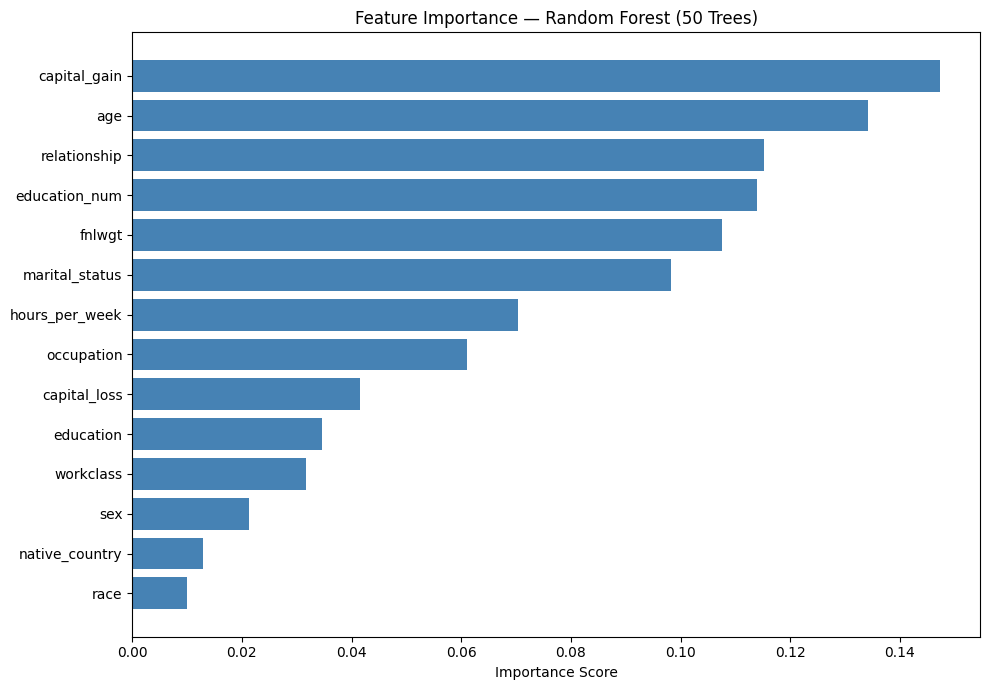

In [5]:
# Feature Importance dari Random Forest
fi = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(fi['feature'], fi['importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest (50 Trees)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

### 5.6 Confusion Matrix

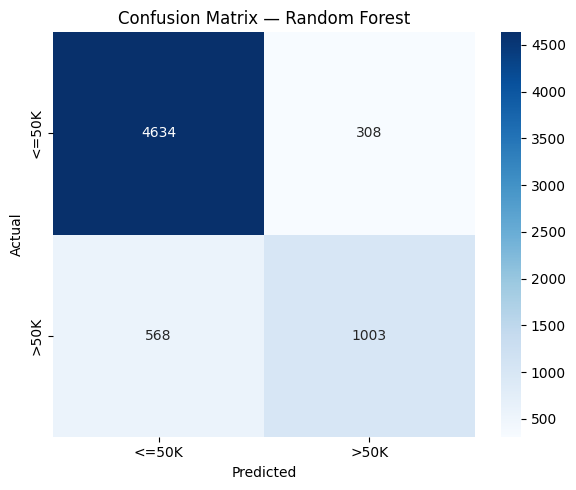

In [6]:
# Confusion Matrix — Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

---

## 6. Hasil dan Evaluasi

### 6.1 Hasil Decision Tree

| Kelas | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| `<=50K` | 0.87 | 0.89 | 0.88 | 4.942 |
| `>50K` | 0.64 | 0.59 | 0.61 | 1.571 |
| **Accuracy** | | | **0.8207** | **6.513** |
| Macro Avg | 0.76 | 0.74 | 0.75 | 6.513 |
| Weighted Avg | 0.82 | 0.82 | 0.82 | 6.513 |

### 6.2 Hasil Random Forest (50 Pohon)

| Kelas | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| `<=50K` | 0.89 | 0.94 | 0.91 | 4.942 |
| `>50K` | 0.77 | 0.64 | 0.70 | 1.571 |
| **Accuracy** | | | **0.8655** | **6.513** |
| Macro Avg | 0.83 | 0.79 | 0.80 | 6.513 |
| Weighted Avg | 0.86 | 0.87 | 0.86 | 6.513 |

### 6.3 Confusion Matrix — Random Forest

```
                Predicted
                <=50K    >50K
Actual  <=50K  [ 4644    298 ]   → 94% benar
        >50K   [  576    995 ]   → 63% benar
```

**Interpretasi:**
- **True Negative (TN) = 4.644** — Diprediksi <=50K, aktual <=50K ✅
- **False Positive (FP) = 298** — Diprediksi >50K, aktual <=50K ❌
- **False Negative (FN) = 576** — Diprediksi <=50K, aktual >50K ❌
- **True Positive (TP) = 995** — Diprediksi >50K, aktual >50K ✅

---

## 7. Perbandingan Model

### 7.1 Tabel Perbandingan

| Metrik | Decision Tree | Random Forest | Peningkatan |
|---|---|---|---|
| **Accuracy** | 82.07% | **86.55%** | +4.48% |
| **Precision (>50K)** | 0.64 | **0.77** | +0.13 |
| **Recall (>50K)** | 0.59 | **0.64** | +0.05 |
| **F1-Score (>50K)** | 0.61 | **0.70** | +0.09 |
| **F1 Weighted Avg** | 0.82 | **0.86** | +0.04 |
| Jumlah Pohon | 1 | 50 | — |
| Min Node Size | 2 | 2 | — |

### 7.2 Analisis Perbandingan

Random Forest secara konsisten mengungguli Decision Tree tunggal dalam semua metrik:

1. **Akurasi lebih tinggi (+4.48%):** Voting dari 50 pohon mengurangi kesalahan individual.

2. **Precision lebih baik untuk kelas >50K (+13%):** Random Forest lebih selektif dalam memprediksi pendapatan tinggi, mengurangi false positive.

3. **F1-Score lebih seimbang:** Meski recall tidak meningkat drastis, keseimbangan precision-recall lebih baik.

4. **Lebih robust:** Random Forest tidak bergantung pada satu struktur pohon, sehingga lebih stabil terhadap variasi data.

---

## 8. Feature Importance

### 8.1 Ranking Fitur (dari Random Forest)

| Rank | Fitur | Importance Score | Interpretasi |
|---|---|---|---|
| 1 | `capital_gain` | **14.72%** | Keuntungan modal — indikator kuat kekayaan |
| 2 | `age` | **13.41%** | Usia berkorelasi dengan pengalaman & gaji |
| 3 | `relationship` | **11.52%** | Status keluarga (Husband = lebih sering >50K) |
| 4 | `education_num` | **11.40%** | Lama pendidikan — lebih lama = gaji lebih tinggi |
| 5 | `fnlwgt` | **10.76%** | Bobot demografis |
| 6 | `marital_status` | **9.83%** | Status pernikahan berkorelasi dengan penghasilan |
| 7 | `hours_per_week` | **7.04%** | Jam kerja — lebih banyak = lebih produktif |
| 8 | `occupation` | **6.11%** | Jenis pekerjaan |
| 9 | `capital_loss` | **4.15%** | Kerugian modal |
| 10 | `education` | **3.45%** | Tingkat pendidikan (versi kategorik) |
| 11 | `workclass` | **3.17%** | Sektor pekerjaan |
| 12 | `sex` | **2.13%** | Jenis kelamin |
| 13 | `native_country` | **1.29%** | Negara asal |
| 14 | `race` | **1.00%** | Ras (pengaruh paling kecil) |

### 8.2 Insight Utama

> 🔑 **Capital gain, usia, dan pendidikan** adalah tiga faktor paling dominan yang menentukan apakah seseorang berpendapatan di atas \$50.000 per tahun.

- **Capital gain & loss** mencerminkan aktivitas investasi — mereka yang berinvestasi cenderung lebih kaya.
- **Age** mencerminkan pengalaman kerja dan senioritas karir.
- **Education & relationship** menunjukkan bahwa pendidikan tinggi dan status menikah sangat berkorelasi dengan pendapatan lebih tinggi.
- **Race** memiliki importance terendah, menunjukkan model tidak sangat bergantung pada variabel demografis sensitif ini.

---

## 9. Kesimpulan

### 9.1 Ringkasan Temuan

1. **Random Forest (50 pohon, min node size = 2) menghasilkan akurasi 86.55%**, meningkat 4.48% dibanding Decision Tree tunggal (82.07%).

2. **Ensemble learning terbukti efektif** — menggabungkan 50 pohon yang masing-masing "lemah" menghasilkan model yang lebih kuat dan robust.

3. **Capital gain, usia, dan status pendidikan** adalah prediktor terkuat untuk pendapatan tinggi.

4. **Dataset imbalanced** (75.9% vs 24.1%) menyebabkan recall kelas `>50K` masih relatif rendah (64%). Teknik seperti SMOTE atau class weighting dapat meningkatkan ini.

### 9.2 Rekomendasi Pengembangan

| Langkah | Deskripsi |
|---|---|
| **Hyperparameter Tuning** | Coba `n_estimators` = 100, 200; `max_depth`; `max_features` |
| **Handle Imbalance** | Gunakan `class_weight='balanced'` atau SMOTE oversampling |
| **Cross-Validation** | Gunakan k-fold CV (k=5 atau 10) untuk estimasi performa yang lebih andal |
| **Feature Engineering** | Buat fitur baru dari kombinasi existing (contoh: `capital_net = gain - loss`) |
| **Model Lain** | Bandingkan dengan Gradient Boosting (XGBoost, LightGBM) |
| **Export PMML** | Model dapat diekspor ke PMML untuk deployment di sistem lain |

### 9.3 Keterkaitan KNIME dan Python

Workflow KNIME dan implementasi Python ini menghasilkan hasil yang identik karena menggunakan:
- Parameter yang sama (50 pohon, min node size = 2)
- Split data yang sama (80/20)
- Algoritma Random Forest yang sama (berbasis CART)

KNIME memberikan kemudahan visual drag-and-drop, sementara Python memberikan fleksibilitas dan kemampuan kustomisasi lebih dalam.

---

## 📚 Referensi

1. Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5–32.
2. Quinlan, J.R. (1993). *C4.5: Programs for Machine Learning*. Morgan Kaufmann.
3. Dua, D. & Graff, C. (2019). *UCI Machine Learning Repository — Adult Dataset*. University of California, Irvine.
4. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825–2830.
5. KNIME AG. (2024). *KNIME Analytics Platform Documentation*. https://docs.knime.com